In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("employee_data.csv")
df.head()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Division,DOB,State,JobFunctionDescription,GenderCode,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,Finance & Accounting,07-10-1969,MA,Accounting,Female,34904,White,Widowed,Fully Meets,4
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,Aerial,30-08-1965,MA,Labor,Male,6593,Hispanic,Widowed,Fully Meets,3
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,General - Sga,06-10-1991,MA,Assistant,Male,2330,Hispanic,Widowed,Fully Meets,4
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,Finance & Accounting,04-04-1998,ND,Clerk,Male,58782,Other,Single,Fully Meets,2
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,General - Con,29-08-1969,FL,Laborer,Female,33174,Other,Married,Fully Meets,3


In [91]:
df.shape

(3000, 26)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   EmpID                       3000 non-null   int64 
 1   FirstName                   3000 non-null   object
 2   LastName                    3000 non-null   object
 3   StartDate                   3000 non-null   object
 4   ExitDate                    1533 non-null   object
 5   Title                       3000 non-null   object
 6   Supervisor                  3000 non-null   object
 7   ADEmail                     3000 non-null   object
 8   BusinessUnit                3000 non-null   object
 9   EmployeeStatus              3000 non-null   object
 10  EmployeeType                3000 non-null   object
 11  PayZone                     3000 non-null   object
 12  EmployeeClassificationType  3000 non-null   object
 13  TerminationType             3000 non-null   obje

## Data Cleaning

In [93]:
df['EmpID'].nunique()

3000

In [94]:
# --- missing values
Missing = df.isnull().sum()
Missing[Missing > 0]

ExitDate                  1467
TerminationDescription    1467
dtype: int64

In [95]:
# --- drop duplicates if any
df.drop_duplicates(subset = "EmpID", inplace = True)

In [96]:
# --- Strip whitespaces
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

# --- Changing datatype of dates
for col in ["StartDate", "ExitDate", "DOB"]:
    df[col] = pd.to_datetime(df[col], dayfirst = True, errors = "coerce")

print("Date dtypes after parse:")
print(df[["StartDate","ExitDate","DOB"]].dtypes)


Date dtypes after parse:
StartDate    datetime64[ns]
ExitDate     datetime64[ns]
DOB          datetime64[ns]
dtype: object


In [97]:
# --- To get age and tenure as of today
ref_date = pd.Timestamp("2026-05-01")  
df["Age"] = ((ref_date - df["DOB"]).dt.days / 365.25).astype(int)
df["TenureYears"] = ((ref_date - df["StartDate"]).dt.days / 365.25).round(2)

# --- Active vs terminated employees
df["IsActive"] = df["EmployeeStatus"] == "Active"

print(df[["Age","TenureYears","IsActive"]].describe())

               Age  TenureYears
count  3000.000000  3000.000000
mean     54.143667     5.243900
std      17.688037     1.444308
min      24.000000     2.740000
25%      38.000000     4.000000
50%      54.000000     5.220000
75%      69.000000     6.490000
max      84.000000     7.730000


In [174]:
# --- Derive MonthlyIncome proxy
# PayZone describes broad compensation bands; EmployeeType adjusts hours
# Zone A ≈ $3,000 | Zone B ≈ $5,500 | Zone C ≈ $8,500  
zone_base = {"Zone A": 3000, "Zone B": 5500, "Zone C": 8500}
type_mult = {"Full-Time": 1.0, "Part-Time": 0.6, "Contract": 0.85}

df["MonthlyIncome"] = (
    df["PayZone"].map(zone_base) * df["EmployeeType"].map(type_mult)
).round(2)

print("Monthly Income Summary:")
print(df["MonthlyIncome"].describe().reset_index())

Monthly Income Summary:
   index  MonthlyIncome
0  count    3000.000000
1   mean    4589.100000
2    std    2117.824946
3    min    1800.000000
4    25%    3000.000000
5    50%    4675.000000
6    75%    5500.000000
7    max    8500.000000


In [83]:
df.head(10)

,empid,firstname,lastname,startdate,exitdate,title,supervisor,ademail,businessunit,employeestatus,...,gendercode,locationcode,racedesc,maritaldesc,performance score,current employee rating,age,tenureyears,isactive,monthlyincome
0,3427,Uriah,Bridges,2019-09-20,NaT,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,Female,34904,White,Widowed,Fully Meets,4,56,6.61,True,7225.0
1,3428,Paula,Small,2023-02-11,NaT,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,Male,6593,Hispanic,Widowed,Fully Meets,3,60,3.22,True,2550.0
2,3429,Edward,Buck,2018-12-10,NaT,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,Male,2330,Hispanic,Widowed,Fully Meets,4,34,7.39,True,5500.0
3,3430,Michael,Riordan,2021-06-21,NaT,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,Male,58782,Other,Single,Fully Meets,2,28,4.86,True,2550.0
4,3431,Jasmine,Onque,2019-06-29,NaT,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,Female,33174,Other,Married,Fully Meets,3,56,6.84,True,2550.0
5,3432,Maruk,Fraval,2020-01-17,NaT,Area Sales Manager,Sheri Campos,maruk.fraval@bilearner.com,BPC,Active,...,Male,6050,Black,Married,Fully Meets,3,77,6.29,True,4675.0
6,3433,Latia,Costa,2022-04-06,2023-07-03,Area Sales Manager,Jacob Braun,latia.costa@bilearner.com,WBL,Active,...,Female,90007,Hispanic,Divorced,Exceeds,4,83,4.07,True,5500.0
7,3434,Sharlene,Terry,2020-11-06,2023-01-29,Area Sales Manager,Tracy Marquez,sharlene.terry@bilearner.com,CCDR,Active,...,Female,97756,White,Divorced,Fully Meets,2,69,5.48,True,7225.0
8,3435,Jac,McKinzie,2018-08-18,NaT,Area Sales Manager,Sharon Becker,jac.mckinzie@bilearner.com,NEL,Active,...,Male,78789,Black,Widowed,Exceeds,3,51,7.70,True,4675.0
9,3436,Joseph,Martins,2022-01-21,2023-06-29,Area Sales Manager,George Jenkins,joseph.martins@bilearner.com,BPC,Active,...,Male,78207,Asian,Widowed,Fully Meets,5,76,4.27,True,3300.0


### Department Summary

In [116]:
df["DeptAvgSalary"] = df.groupby("DepartmentType")["MonthlyIncome"].transform("mean")
df["SalaryvsAvg"] = df["MonthlyIncome"] - df["DeptAvgSalary"]
df["SalaryvsAvgPct"] = (df["SalaryvsAvg"] / df["DeptAvgSalary"] * 100).round(2)

q2 = (df[["EmpID","FirstName","DepartmentType","MonthlyIncome",
          "DeptAvgSalary","SalaryvsAvg","SalaryvsAvgPct"]]
      .sort_values("DepartmentType"))

dept_summary = (df.groupby("DepartmentType")["MonthlyIncome"]
                  .agg(["mean","min","max","count"])
                  .rename(columns = {"mean":"AvgSalary","min":"MinSalary",
                                   "max":"MaxSalary","count":"HeadCount"})
                  .round(2)
                  .reset_index())
print(dept_summary.to_string(index = False))

      DepartmentType  AvgSalary  MinSalary  MaxSalary  HeadCount
       Admin Offices    4318.75     1800.0     8500.0         80
    Executive Office    4145.83     1800.0     8500.0         24
               IT/IS    4550.35     1800.0     8500.0        430
          Production    4596.19     1800.0     8500.0       2020
               Sales    4666.16     1800.0     8500.0        331
Software Engineering    4668.26     1800.0     8500.0        115


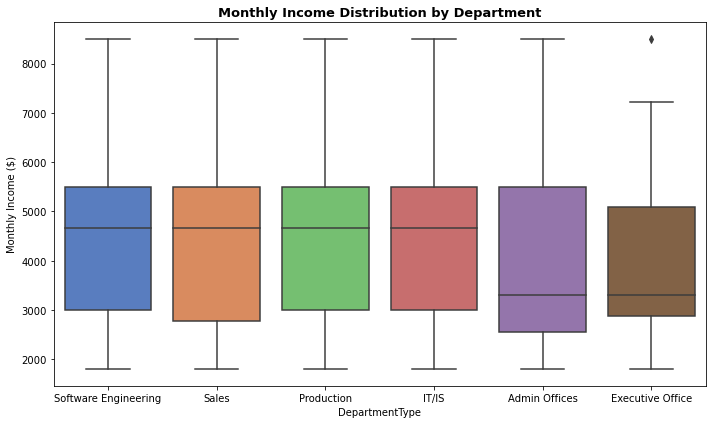

In [108]:
import seaborn as sns

fig, ax = plt.subplots(figsize = (10,6))
dept_order = dept_summary.sort_values('AvgSalary', ascending = False)['DepartmentType']
sns.boxplot(data = df, x = "DepartmentType", y = "MonthlyIncome", order = dept_order, palette = "muted", ax = ax)
ax.set_title("Monthly Income Distribution by Department", fontsize = 13, fontweight = "bold")
ax.set_ylabel("Monthly Income ($)")
plt.tight_layout()
plt.show()

### Ranking Employees within each Department

In [101]:
df["SalaryRank"] = (
    df.groupby("DepartmentType")["MonthlyIncome"]
    .rank(method = "dense", ascending = False)
    .astype(int)
)

q1 = (df[["EmpID","FirstName","LastName","DepartmentType","MonthlyIncome","SalaryRank"]]
      .sort_values(["DepartmentType","SalaryRank"])
      .reset_index(drop=True))

print("Top 5 earners per department:")
q1.groupby("DepartmentType").head(5).reset_index(drop = True)

Top 5 earners per department:


,EmpID,FirstName,LastName,DepartmentType,MonthlyIncome,SalaryRank
0,1045,Elliott,Ashley,Admin Offices,8500.0,1
1,1331,Roger,Taylor,Admin Offices,8500.0,1
2,1357,Angeline,Perez,Admin Offices,8500.0,1
3,1362,Raphael,Francis,Admin Offices,8500.0,1
4,1378,Konnor,Rivas,Admin Offices,8500.0,1
5,2424,Jonathon,Montes,Executive Office,8500.0,1
6,3834,Monique,Pierce,Executive Office,7225.0,2
7,3914,Nathanial,Booth,Executive Office,7225.0,2
8,3927,Misael,Hunter,Executive Office,7225.0,2
9,3822,Katrina,Lambert,Executive Office,5500.0,3


### Top 10% Earners 

In [113]:
threshold_90 = df["MonthlyIncome"].quantile(0.90)
print(f"Top 10% salary threshold: ${threshold_90:,.2f}/month")

top10 = df[df["MonthlyIncome"] >= threshold_90][
    ["EmpID","FirstName","LastName","Title","DepartmentType",
     "MonthlyIncome","TenureYears","Performance Score"]
].sort_values("MonthlyIncome", ascending=False).reset_index(drop = True)

print(f"\nCount of top-10% earners: {len(top10)}")
top10.head(10)

Top 10% salary threshold: $8,500.00/month

Count of top-10% earners: 339


,EmpID,FirstName,LastName,Title,DepartmentType,MonthlyIncome,TenureYears,Performance Score
0,3438,Dheepa,Nguyen,Area Sales Manager,Sales,8500.0,7.72,Fully Meets
1,2448,Kristin,Hickman,Production Manager,Production,8500.0,5.52,Fully Meets
2,2511,Ernesto,Beltran,Software Engineer,Software Engineering,8500.0,5.23,Fully Meets
3,2506,Trey,Johnston,Director of Operations,IT/IS,8500.0,3.84,Fully Meets
4,2500,Annabelle,Frederick,Software Engineer,Software Engineering,8500.0,6.77,Fully Meets
5,2497,Marilyn,Chaney,Director of Operations,IT/IS,8500.0,4.80,Fully Meets
6,2492,Natalya,Norman,Software Engineer,Software Engineering,8500.0,6.78,Fully Meets
7,2470,Cesar,Hunter,Production Manager,Production,8500.0,5.22,Fully Meets
8,2453,Mila,Poole,Production Manager,Production,8500.0,2.97,Fully Meets
9,2452,Fabian,Mullins,Production Manager,Production,8500.0,3.55,Fully Meets


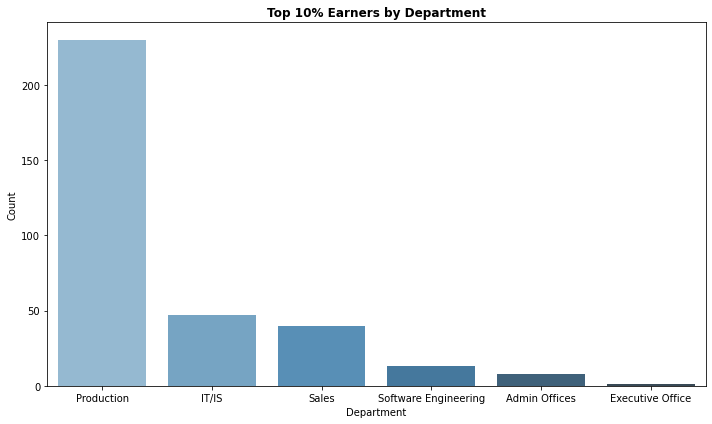

In [128]:
top10_dept = (top10.groupby("DepartmentType")
                   .size()
                   .reset_index(name = "Top10Count")
                   .sort_values("Top10Count", ascending = False))

fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(data = top10_dept, x = "DepartmentType", y = "Top10Count", palette = "Blues_d", ax = ax)
ax.set_title("Top 10% Earners by Department", fontsize = 12, fontweight = "bold")
ax.set_xlabel("Department")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Attrition Rate by Job Role and Department

In [148]:
# --- Attrition is any non-active status employee
df["IsAttrited"] = ~df["IsActive"]

# --- Department wise
dept_attrition = (df.groupby("DepartmentType")
                    .agg(Total = ("EmpID","count"), Attrited = ("IsAttrited","sum"))
                    .assign(AttritionRate = lambda x: (x["Attrited"] / x["Total"] * 100).round(2))
                    .sort_values("AttritionRate", ascending = False)
                    .reset_index())

print("Attrition by Department:")
print(dept_attrition.to_string(index = False))

Attrition by Department:
      DepartmentType  Total  Attrited  AttritionRate
          Production   2020       432          21.39
Software Engineering    115        23          20.00
               IT/IS    430        55          12.79
               Sales    331        30           9.06
       Admin Offices     80         2           2.50
    Executive Office     24         0           0.00


In [147]:
# --- Job Role wise
role_attrition = (df.groupby("Title")
                    .agg(Total = ("EmpID","count"), Attrited = ("IsAttrited","sum"))
                    .assign(AttritionRate = lambda x: (x["Attrited"] / x["Total"] * 100).round(2))
                    .sort_values("AttritionRate", ascending=False).reset_index())

print("Attrition by Jon Role:")
print(role_attrition.to_string(index = False))

Attrition by Jon Role:
                       Title  Total  Attrited  AttritionRate
        Enterprise Architect      5         4          80.00
              Data Architect      5         4          80.00
                     Sr. DBA      8         4          50.00
    Principal Data Architect      8         3          37.50
                 BI Director     11         4          36.36
                         CIO     11         4          36.36
Software Engineering Manager     10         3          30.00
    Production Technician II    516       149          28.88
                BI Developer     44        12          27.27
      Database Administrator     25         6          24.00
           Software Engineer     90        21          23.33
              Sr. Accountant     13         3          23.08
          Production Manager    154        30          19.48
     Production Technician I   1321       256          19.38
        Sr. Network Engineer     50         9          18.00
 

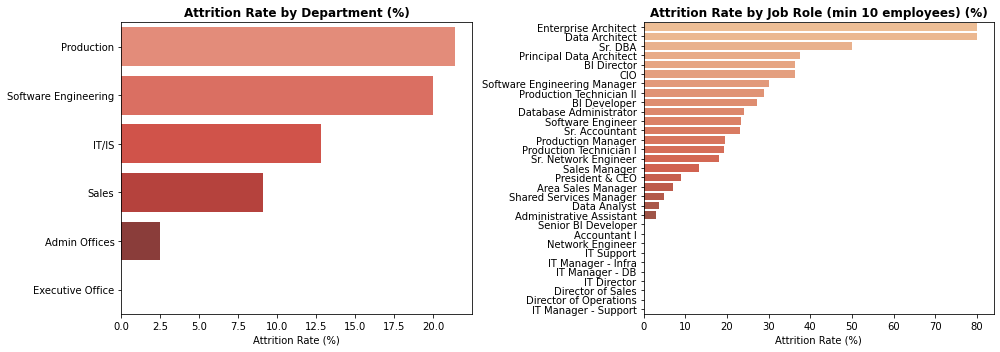

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Dept chart
sns.barplot(data = dept_attrition, y = "DepartmentType", x = "AttritionRate", palette = "Reds_d", ax = axes[0])
axes[0].set_title("Attrition Rate by Department (%)", fontweight = "bold")
axes[0].set_xlabel("Attrition Rate (%)")
axes[0].set_ylabel("")

# --- Role chart
sns.barplot(data = role_attrition, y = "Title", x = "AttritionRate", palette = "OrRd_d", ax = axes[1])
axes[1].set_title("Attrition Rate by Job Role (min 10 employees) (%)", fontweight = "bold")
axes[1].set_xlabel("Attrition Rate (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Performance Distribution and Employee Stagnation

In [164]:
perf_map = {"PIP": 1, "Needs Improvement": 2, "Fully Meets": 3, "Exceeds": 4}
df["PerformanceScore_Num"] = df["Performance Score"].map(perf_map)

stagnant = df[(df["IsActive"] == True) & (df["TenureYears"] > 5)][["EmpID","FirstName","LastName","Title","DepartmentType",
   "TenureYears","Performance Score","PerformanceScore_Num",
   "PayZone","MonthlyIncome"]].sort_values("TenureYears", ascending=False).reset_index(drop=True)

print(f"Employees active for more than 5 years in same role: {len(stagnant)}")
stagnant.head(10)

Employees active for more than 5 years in same role: 1335


,EmpID,FirstName,LastName,Title,DepartmentType,TenureYears,Performance Score,PerformanceScore_Num,PayZone,MonthlyIncome
0,1892,Saniya,Buck,Production Technician II,Production,7.73,Fully Meets,3,Zone A,2550.0
1,3290,Jaiden,Middleton,Production Technician I,Production,7.73,Fully Meets,3,Zone A,1800.0
2,1352,Lily,Tyler,Sr. Network Engineer,Admin Offices,7.73,Fully Meets,3,Zone B,4675.0
3,2168,Rashad,Mayo,Production Technician II,Production,7.73,Exceeds,4,Zone B,3300.0
4,2911,Estrella,Ho,Production Technician I,Production,7.73,Exceeds,4,Zone A,1800.0
5,3248,Micah,Douglas,Production Technician I,Production,7.73,Fully Meets,3,Zone B,4675.0
6,3872,Lorena,Rice,IT Support,IT/IS,7.72,Fully Meets,3,Zone B,4675.0
7,3820,Anita,Shepard,Network Engineer,IT/IS,7.72,Fully Meets,3,Zone C,7225.0
8,2811,Phoenix,Farley,Production Technician I,Production,7.72,Fully Meets,3,Zone A,1800.0
9,3960,Andreas,Torres,CIO,IT/IS,7.72,Fully Meets,3,Zone A,1800.0


High performers stagnating (>5 yrs, no promotion signal): 1223


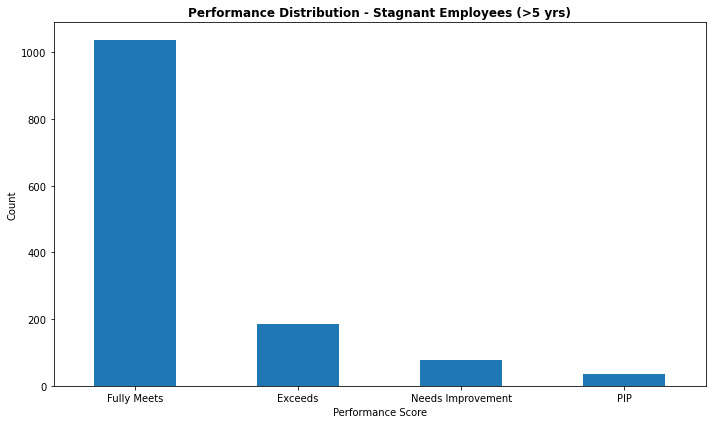

In [177]:
high_perf_stagnant = stagnant[stagnant["Performance Score"].isin(["Exceeds","Fully Meets"])]
print(f"High performers stagnating (>5 yrs, no promotion signal): {len(high_perf_stagnant)}")

fig, ax = plt.subplots(figsize = (10, 6))
stagnant["Performance Score"].value_counts().plot(kind = "bar", ax = ax)
ax.set_title("Performance Distribution - Stagnant Employees (>5 yrs)", fontweight = "bold")
ax.set_xlabel("Performance Score")
ax.set_ylabel("Count")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [179]:
df.to_csv("C:/Users/Dhruv/Downloads/projects/employee_data.csv",index=False)